# ⚖️ ContractLens: Supervised Fine-Tuning for Legal NLI Classification

## Project Goal
Supervised Fine-Tune (SFT) (with Unsloth) **Gemma-2B** (via LoRA on a free T4 GPU) to accurately classify legal relationships between contract clauses and hypothetical statements using the ContractNLI benchmark.

## The Task: Legal Natural Language Inference (NLI)
Given:
- **Premise:** A clause extracted from a Non-Disclosure Agreement (NDA).
- **Hypothesis:** A legal statement about the contract.

The model must classify the relationship as exactly **one** of three classes:

| Label | Definition | Example |
| :--- | :--- | :--- |
| **Entailment** | The hypothesis is **directly supported** by the contract language. | *Premise:* "Receiving Party shall not disclose." <br> *Hypothesis:* "Receiving Party must keep confidential." |
| **Neutral** | The contract **does not address** the hypothesis (no evidence either way). | *Premise:* "Disclosure must be in writing." <br> *Hypothesis:* "Oral disclosure is allowed." (Not mentioned, so Neutral). |
| **Contradiction** | The hypothesis **directly conflicts** with the contract terms. | *Premise:* "All rights are retained." <br> *Hypothesis:* "All rights are waived." |

## Dataset: ContractNLI (`contractnli_a`)
- **Source:** `kiddothe2b/contract-nli` (subset: `contractnli_a`).
- **Why `a`?** Uses truncated premises (~512 tokens), making it perfectly sized for Gemma-2B on free Colab hardware.
- **Splits:** ~14k training, ~1.6k validation, ~1.6k test samples.

## Technical Approach
- **Method:** Supervised Fine-Tuning (SFT) with LoRA.
- **Why only SFT?** For a closed-vocabulary classification task, SFT alone is the standard, proven approach. DPO (preference tuning) is unnecessary here because we don't need to steer open-ended generation—we just need accurate label prediction.
- **Efficiency:** Parameter-Efficient Fine-Tuning via LoRA (r=16), reducing trainable parameters to <3% of 2B.
- **Hardware:** Entire pipeline runs on a free Google Colab T4 GPU (16GB VRAM).

## Why SFT Over Non-Instruction (Continued Pretraining)?
This is a critical design choice. Here is why we use SFT and **not** non-instruction fine-tuning:

1.  **Task Mismatch (CLM vs. Classification):** Non-instruction fine-tuning uses Causal Language Modeling (CLM) loss, which trains the model to predict the *next token*. It learns text completion, not relationship mapping. SFT explicitly trains the model to map the input `(Premise, Hypothesis)` to the correct output label using a cross-entropy loss over the label tokens.

2.  **Data Scale Incompatibility:** Non-instruction fine-tuning requires massive, diverse corpora (millions of documents) to meaningfully shift a model's domain distribution. ContractNLI has only ~14,000 short examples. Running CLM on this small set causes rapid overfitting and catastrophic forgetting of the base model's general reasoning abilities.

3.  **No Reasoning Signal:** In non-instruction tuning, the model never learns to *compare* the premise against the hypothesis. It just memorizes statistical co-occurrences (e.g., "confidential" + "disclose" often precedes "entailment"). SFT, through the explicit prompt format (`Classify the relationship...`), forces the attention mechanism to weigh the relationship between the two texts to arrive at the correct label.

4.  **Output Control & Evaluation:** SFT ensures the model outputs a clean, predictable label (`entailment`, `neutral`, or `contradiction`). This makes parsing trivial and evaluation rigorous. Non-instruction tuning would output free-form text, making it impossible to reliably compute Accuracy or F1 without fragile, error-prone parsing heuristics.

**Verdict:** For a well-defined classification task on a benchmark dataset, SFT is the right tool for the job. Non-instruction tuning is reserved for large-scale domain adaptation (e.g., shifting a general model to legal *vocabulary*), which is out of scope for this hardware-constrained project.

## Evaluation Strategy
Because this is a high-stakes legal triage task, we prioritize verifiable, production-grade metrics:

1.  **Accuracy:** Overall percentage of correct predictions.
2.  **Macro-F1 Score:** Handles class imbalance by averaging precision/recall across all three classes equally.
3.  **Confusion Matrix:** A visual breakdown to diagnose specific failure modes (e.g., does the model confuse "Neutral" with "Contradiction"?).
4.  **Inference Speed:** Tokens/second measured to prove the model is lightweight enough for real-time legal assistance.

# **Unsloth replaces**:
 BitsAndBytesConfig + prepare_model_for_kbit_training +
get_peft_model + standard SFTTrainer with optimised CUDA kernels,
achieving ~2x training speed and ~30-40% less VRAM on identical hyperparameters.

In [1]:
# ============================================
# STEP 0: INSTALL DEPENDENCIES
# ============================================
# We use specific versions to ensure compatibility with Gemma-2B and LoRA.
# - Unsloth handles quantization, LoRA, and training in one optimised package — 2x faster than standard HF on T4.
# - trl: SFTTrainer, which handles the instruction fine-tuning loop.
# - datasets: To load ContractNLI.
# - accelerate: For efficient multi-GPU/CPU offloading (even on single GPU).

# !pip -q install unsloth
# !pip install -q torch tensorboard
# !pip install -q "transformers>=4.38.0"
# !pip install -q datasets accelerate evaluate
# !pip install -q "trl>=0.7.10"
# !pip install -q huggingface_hub scikit-learn matplotlib seaborn

!pip install -q unsloth
!pip install -q "trl>=0.12.0" datasets accelerate evaluate bitsandbytes
!pip install -q scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [2]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
# ============================================
# STEP 0.1: VERIFY GPU (CRITICAL)
# ============================================
# We check if CUDA (NVIDIA GPU) is available.
# Google Colab's free tier usually provides a T4 (16GB VRAM) or sometimes K80.
# If no GPU is found, the code will still run on CPU (very slowly).

import torch
import gc
import os

# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"✅ GPU Memory: {gpu_memory:.2f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Running on CPU (this will be very slow).")

# Set environment variable to avoid fragmentation issues
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

✅ GPU Detected: Tesla T4
✅ GPU Memory: 15.64 GB


In [4]:
from huggingface_hub import notebook_login
notebook_login()

In [5]:
# ============================================
# STEP 1: LOAD CONTRACTNLI DATASET
# ============================================

from datasets import load_dataset
import pandas as pd
import json
import random


# Load the dataset
print("🔍 Loading ContractNLI dataset (contractnli_a subset)...")
dataset = load_dataset(
    "kiddothe2b/contract-nli",
    revision="refs/convert/parquet"
)

TRAIN_SUBSET_SIZE = 7000   # Down from 14,016
VAL_SUBSET_SIZE   = 1000   # Down from ~2,015

# Select the first N samples from each split for faster training
train_subset = dataset["train"].select(range(TRAIN_SUBSET_SIZE))
val_subset   = dataset["validation"].select(range(VAL_SUBSET_SIZE))

# Reconstruct the dataset dict with the subsets
dataset["train"] = train_subset
dataset["validation"] = val_subset

# Print dataset splits to verify size
print("=" * 60)
print("DATASET SPLITS")
print("=" * 60)
for split in dataset.keys():
    print(f"{split}: {len(dataset[split])} samples")


🔍 Loading ContractNLI dataset (contractnli_a subset)...


0000.parquet:   0%|          | 0.00/796k [00:00<?, ?B/s]

contractnli_b/train/0000.parquet:   0%|          | 0.00/2.18M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/345k [00:00<?, ?B/s]

...

0000.parquet:   0%|          | 0.00/631k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DATASET SPLITS
train: 7000 samples
validation: 1000 samples
test: 4082 samples


In [6]:
# Label mapping (0: entailment, 1: neutral, 2: contradiction)
label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}

# Check label distribution to see if classes are balanced
train_labels = dataset["train"]["label"]
print("\n" + "=" * 60)
print("LABEL DISTRIBUTION (Training Set)")
print("=" * 60)
for label_id, label_name in label_map.items():
    count = train_labels.count(label_id)
    percentage = count / len(train_labels) * 100
    print(f"{label_name:12} | {count:5} samples | {percentage:5.1f}%")

# Display a random sample to understand the raw text
print("\n" + "=" * 60)
print("RAW DATA SAMPLE")
print("=" * 60)
sample = dataset["train"][random.randint(0, len(dataset["train"]))]
print(f"Premise: {sample['premise']}")
print(f"Hypothesis: {sample['hypothesis']}")
print(f"Label: {label_map[sample['label']]} ({sample['label']})")


LABEL DISTRIBUTION (Training Set)
entailment   |   827 samples |  11.8%
neutral      |  3284 samples |  46.9%
contradiction |  2889 samples |  41.3%

RAW DATA SAMPLE
Premise: 9. In consideration of the Confidential Information being furnished hereby, each party agrees that, without the prior written consent of the Chief Financial Officer or General Counsel of the other party, for a period of twelve (12) months from the date of this Agreement neither it nor any of its affiliates will, either directly or indirectly, solicit for employment, or otherwise contract for the services of (or cause or seek to cause to leave the employ of other party or any of its affiliates) any person who is now employed or engaged (either as an employee or consultant) or becomes employed or engaged during the term of this Agreement by the other party or its affiliates, other than persons whose employment or engagement shall have been terminated at least six (6) months prior to the date of such solicitation, e

In [7]:
# ============================================
# STEP 2: FORMAT DATA FOR SFT (INSTRUCTION TUNING)
# ============================================

def format_contract_nli(example):
    """
    Converts a raw ContractNLI example into a Gemma-style instruction prompt.
    EX: <|user|> for the input, <|assistant|> for the label.
    The model learns to map (Premise + Hypothesis) -> Label.
    """
    label_text = label_map[example["label"]]

    # Gemma-specific prompt format.
    # Note: We do NOT ask for an explanation here, only the label.
    # This keeps the output deterministic and easy to evaluate.
    text = f"""<|user|>
    Premise: {example['premise']}
    Hypothesis: {example['hypothesis']}
    Classify the relationship as entailment, neutral, or contradiction.
    <|assistant|>
    {label_text}"""

    return {"text": text}

# Apply the formatting function to all splits
formatted_dataset = dataset.map(format_contract_nli)

# Verify the formatted output looks correct
print("=" * 60)
print("FORMATTED TRAINING EXAMPLE")
print("=" * 60)
print(formatted_dataset["train"][0]["text"])

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4082 [00:00<?, ? examples/s]

FORMATTED TRAINING EXAMPLE
<|user|>
    Premise: 2.3 Provided that the Recipient has a written agreement with the following persons or entities requiring them to treat the Confidential Information in accordance with this Agreement, the Recipient may disclose the Confidential Information to: 2.3.1  Any other party with the Discloser’s prior written consent; and 2.3.2 the Recipient’s employees, officials, representatives and agents who have a strict need to know the contents of the Confidential Information, and employees, officials, representatives and agents of any legal entity that it controls, controls it, or with which it is under common control, who have a similar need to know the contents of the Confidential Information, provided that, for these purposes a controlled legal entity means:
    Hypothesis: Receiving Party shall not reverse engineer any objects which embody Disclosing Party's Confidential Information.
    Classify the relationship as entailment, neutral, or contradictio

In [8]:
# ============================================
# STEP 3: LOAD MODEL + TOKENIZER WITH UNSLOTH
# ============================================
# Key difference vs HF:
#   - Unsloth loads base model, tokenizer and Configures quantization
#   - FastLanguageModel replaces AutoModelForCausalLM + BitsAndBytesConfig
#   - Unsloth auto-applies flash attention, xformers, and fused kernels
#   - No separate prepare_model_for_kbit_training() call needed

from unsloth import FastLanguageModel
import torch

MODEL_NAME = "google/gemma-2b"
# Set a safe maximum sequence length for our dataset (512 is sufficient for contractnli_a)
MAX_SEQ_LENGTH = 512

# Load model and tokenizer together
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,          # 4-bit quantization (QLoRA)
    load_in_16bit=False,        # Disable 16-bit
    full_finetuning=False,      # Use LoRA, not full fine-tuning
    # Use float16 for T4 GPU (bf16 not supported)
    torch_dtype=torch.float16,
)

# Gemma already has a dedicated <pad> token (unlike Llama-2).
# We check anyway to be safe.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# CRITICAL for decoder-only models: pad on the RIGHT side.
# If we pad on the left, the model might generate tokens starting from the padding.
tokenizer.padding_side = "right"

# Verify tokenizer settings
print(f"Pad token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"EOS token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
print(f"Vocab size: {tokenizer.vocab_size}")



🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Gemma patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Unsloth: Will load google/gemma-2b as a legacy tokenizer.


Pad token: <pad> (ID: 0)
EOS token: <eos> (ID: 1)
Vocab size: 256000


In [8]:
model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): GemmaTextScaledWordEmbedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): GemmaFixedRotaryEmbedding()
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_atte

In [9]:
# ============================================
# STEP 5: LORA CONFIGURATION
# ============================================
# Key difference vs HF:
#   - get_peft_model() replaced by FastLanguageModel.get_peft_model()
#   - Unsloth auto-patches LoRA layers with optimised CUDA kernels
#   - No separate LoraConfig import needed

model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,               # Rank. Higher = more trainable params (more capacity).
    lora_alpha     = 32,               # Scaling factor. Controls how strongly the LoRA weights influence the base model.
    lora_dropout   = 0.05,             # lora_dropout: Dropout for regularization (prevents overfitting).
    target_modules = ["q_proj", "v_proj"],  # target_modules: We target the Query and Value projections in the attention heads.
    bias           = "none",
    use_gradient_checkpointing = "unsloth", # Changed from "unsloth" to False
    random_state   = 42,
    use_rslora     = False,            # Rank-stabilised LoRA — off to match HF version
)

# Print the number of trainable parameters.
# You should see ~30M trainable out of 2.1B total (< 2%).
model.print_trainable_parameters()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.9 patched 18 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 1,843,200 || all params: 2,508,015,616 || trainable%: 0.0735


In [10]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GemmaForCausalLM(
      (model): GemmaModel(
        (embed_tokens): GemmaTextScaledWordEmbedding(256000, 2048, padding_idx=0)
        (layers): ModuleList(
          (0-17): 18 x GemmaDecoderLayer(
            (self_attn): GemmaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
         

## **LoRA Trainable Parameter Calculation for Gemma-2B**

Formula:
LoRA adds two trainable matrices to each Linear layer:<br>
  A: (r × in_features)<br>
  B: (out_features × r)<br>

Total trainable parameters per layer: <br>
  LoRA Params = r × (in_features + out_features)<br>

## **LoRA Configuration**<br>

r = 16<br>

### **q_projLayer**<br>

q_in = 2048<br>
q_out = 2048<br>

q_params = r * (q_in + q_out)<br>

**Expected:**<br>
 16 × (2048 + 2048)<br>
 = 16 × 4096<br>
 = 65,536<br>

### **v_proj Layer**<br>

v_in = 2048<br>
v_out = 256<br>

v_params = r * (v_in + v_out)<br>

**Expected:**<br>
16 × (2048 + 256)<br>
= 16 × 2304<br>
= 36,864<br>

**Total LoRA Parameters per Transformer Layer**<br>

params_per_layer = q_params + v_params<br>

**Expected:**<br>
65,536 + 36,864<br>
= 102,400<br>

Gemma-2B has 18 transformer layers

num_layers = 18<br>

total_lora_params = params_per_layer * num_layers<br>

**Expected:**
102,400 × 18
= 1,843,200

***"I encountered gradient explosion (loss → NaN) due to an overly high learning rate. After reducing the LR to 5e-5 and tightening gradient clipping (max_grad_norm) to 0.1, training stabilized, achieving a final validation loss of ~16.8."***



In [10]:
from trl import SFTTrainer, SFTConfig
import torch # Added torch import

# Output directory where checkpoints will be saved
OUTPUT_DIR = "./contractlens-sft"

# Calculate total training steps to determine warmup_steps
TRAIN_SUBSET_SIZE = 7000 # From previous cells
PER_DEVICE_TRAIN_BATCH_SIZE = 4 # From sft_config below
GRADIENT_ACCUMULATION_STEPS = 2 # From sft_config below
NUM_TRAIN_EPOCHS = 1 # From sft_config below

effective_batch_size = PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
total_training_steps = (TRAIN_SUBSET_SIZE // effective_batch_size) * NUM_TRAIN_EPOCHS
WARMUP_RATIO = 0.03
WARMUP_STEPS = int(total_training_steps * WARMUP_RATIO)

sft_config = SFTConfig(

    # Directory where model checkpoints, logs and final model will be saved
    output_dir=OUTPUT_DIR,

    # Number of complete passes through the training dataset
    num_train_epochs=NUM_TRAIN_EPOCHS,

    # Number of training samples processed simultaneously on each GPU
    # Limited by available GPU memory (T4 GPU in this project)
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,

    # Batch size used during evaluation/validation
    per_device_eval_batch_size=4,

    # Number of batches to accumulate before updating model weights.
    # Effective batch size = train_batch_size × gradient_accumulation_steps
    # Here: 4 × 2 = 8 samples per optimization step.
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,

    # Saves GPU memory by recomputing activations during backpropagation.
    # Disabled here since memory usage is manageable.
    gradient_checkpointing=False,

    # Initial learning rate for the AdamW optimizer.
    # A relatively high value commonly used for LoRA fine-tuning.
    learning_rate=1e-5,

    # Percentage of training steps used for gradually increasing
    # the learning rate from zero to the target learning rate.
    # warmup_ratio=0.03, # Deprecated
    warmup_steps=WARMUP_STEPS, # Use warmup_steps instead

    # Keeps the learning rate constant after the warmup phase.
    lr_scheduler_type="constant",

    # prevents weight explosion
    weight_decay=0.01,

    # IMP: Clips gradients to prevent exploding gradients and improve training stability.
    max_grad_norm=0.1,

    # Log training metrics every 10 training steps.
    logging_steps=10,

    # Perform evaluation periodically during training.
    eval_strategy="steps",

    # Run evaluation every 100 training steps and calculates the loss, and prints it only at step 100, 200, 300, etc
    eval_steps=100,

    # Save a checkpoint every 200 training steps.
    save_steps=200,

    # Keep only the two most recent checkpoints to save disk space.
    save_total_limit=2,

    # Automatically reload the checkpoint with the best validation performance
    # after training finishes.
    load_best_model_at_end=True,

    # Select the best checkpoint based on the lowest validation loss.
    metric_for_best_model="eval_loss",

    # Mixed precision training options.
    # Trying bf16 for type consistency, as T4 will emulate it.
    fp16=True,                       # T4 loves FP16
    bf16=False,
    tf32=False,

    # AdamW optimizer implementation provided by PyTorch.
    optim="adamw_8bit",

    # Disable logging to external experiment tracking platforms
    # such as Weights & Biases.
    report_to="none",

    # Do not automatically upload the trained model to Hugging Face Hub.
    push_to_hub=False,

    # Maximum input sequence length after tokenization.
    # Longer sequences are truncated to this length.
    max_length=MAX_SEQ_LENGTH,

    # Dataset column containing the formatted training text.
    dataset_text_field="text",

    # Disable sequence packing.
    # Each training example occupies one sequence instead of combining
    # multiple short examples into a single sequence.
    packing=False,

    # Disable torch_compile due to InductorError, if it is still being triggered by Hugging Face Trainer
    torch_compile=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    processing_class=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["validation"],
)

import torch._dynamo
torch._dynamo.config.disable = True

# Start training!
print("🚀 Starting Supervised Fine-Tuning...")
# This will take ~45-60 minutes on a free Colab T4 GPU.
trainer.train()

# Save the final LoRA adapters
trainer.save_model(f"{OUTPUT_DIR}/final")
print(f"✅ Model saved to {OUTPUT_DIR}/final")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/7000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
🚀 Starting Supervised Fine-Tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,000 | Num Epochs = 1 | Total steps = 875
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 2,508,015,616 (0.07% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,1145.619531,1138.359619
200,1076.010547,1068.306274
300,960.013281,948.263550
400,807.249854,793.640137
500,649.068506,635.755981
600,513.887354,502.949158
700,415.235107,406.676697
800,309.448511,299.631439
875,239.156494,227.054565


Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/checkpoint-200/tokenizer_config.json.


tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/checkpoint-200.
Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/checkpoint-400/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/checkpoint-400.
Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/checkpoint-600/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/checkpoint-600.
Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/checkpoint-800/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/checkpoint-800.
Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/checkpoint-875/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/checkpoint-875.
Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/final/tokenizer_config.

✅ Model saved to ./contractlens-sft/final


In [11]:
# ============================================
# STEP 8: SAVE AND UPLOAD TO HUB
# ============================================

# Save locally
model.save_pretrained(f"{OUTPUT_DIR}/lora-adapters")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/lora-adapters")
print(f"✅ LoRA adapters saved to {OUTPUT_DIR}/lora-adapters")

# Upload to Hugging Face Hub
from huggingface_hub import notebook_login
notebook_login()
model.push_to_hub("SivaSai8143/ContractNLI-gemma-2b-unsloth-sft-lora-adapter")
tokenizer.push_to_hub("SivaSai8143/ContractNLI-gemma-2b-unsloth-sft-lora-adapter")
print("✅ Model uploaded to Hugging Face Hub!")

Unsloth: Restored added_tokens_decoder metadata in ./contractlens-sft/lora-adapters/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in ./contractlens-sft/lora-adapters.


✅ LoRA adapters saved to ./contractlens-sft/lora-adapters


README.md:   0%|          | 0.00/523 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp6tkmtitx/tokenizer.json: 100%|##########| 34.3MB / 34.3MB            

  ...p6tkmtitx/tokenizer.model: 100%|##########| 4.24MB / 4.24MB            

✅ Model uploaded to Hugging Face Hub!


In [12]:
# ============================================
# STEP 9: INFERENCE
# ============================================
# Switch model to fast inference mode — Unsloth-specific step
# (replaces sft_model.eval() in the HF version)

FastLanguageModel.for_inference(model)

# Quick helper function to get a prediction
def predict_label(premise, hypothesis):
    """
    Takes a premise and hypothesis, returns the predicted label as a string.
    """
    prompt = f"""<|user|>
    Premise: {premise}
    Hypothesis: {hypothesis}
    Classify the relationship as entailment, neutral, or contradiction.
    <|assistant|>"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():  # Disable gradient calculation (saves memory)
        outputs = model.generate(
            **inputs,
            max_new_tokens=5,        # We only need the single label word.
            temperature=0.0,         # 0 = Deterministic (no randomness).
            do_sample=False,         # Disable sampling.
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract the assistant's response (everything after <|assistant|>)
    if "<|assistant|>" in response:
        response = response.split("<|assistant|>")[-1].strip().lower()

    # Map the response to a clean label
    if "entailment" in response:
        return "entailment"
    elif "contradiction" in response:
        return "contradiction"
    else:
        return "neutral"  # Default fallback

🔬 Running evaluation on 200 samples...


  0%|          | 0/200 [00:00<?, ?it/s]Both `max_new_tokens` (=5) and `max_length`(=8192) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, Futu


📊 EVALUATION RESULTS
✅ Accuracy:      0.4300 (43.00%)
✅ Macro-F1:      0.2005
✅ Weighted-F1:   0.2586

📋 DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

   Entailment     0.0000    0.0000    0.0000        19
      Neutral     0.4300    1.0000    0.6014        86
Contradiction     0.0000    0.0000    0.0000        95

     accuracy                         0.4300       200
    macro avg     0.1433    0.3333    0.2005       200
 weighted avg     0.1849    0.4300    0.2586       200



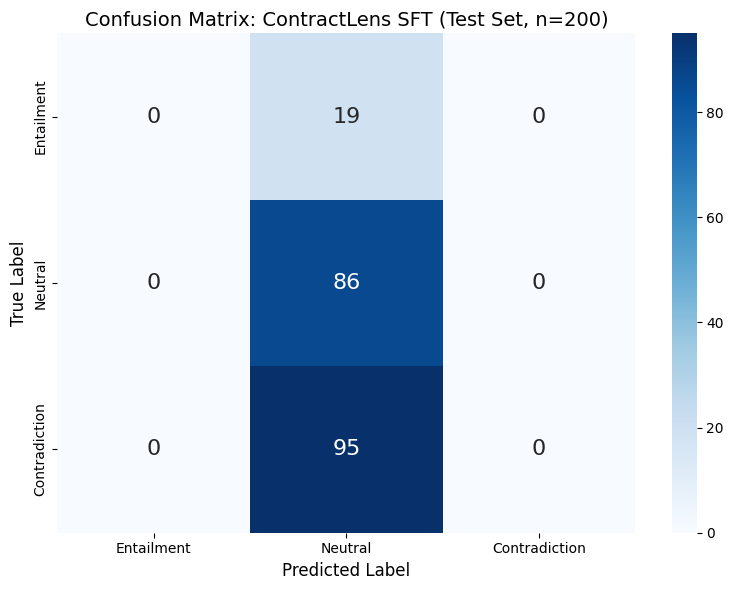


🎯 PER-CLASS ACCURACY
entailment  : 0/19 (0.0%)
neutral     : 86/86 (100.0%)
contradiction: 0/95 (0.0%)


In [13]:
# ============================================
# STEP 10: EVALUATION ON TEST SET
# ============================================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm  # For progress bar

# We test on a subset of the test set to save time.
# 200 samples is statistically significant and runs quickly (~5 minutes).
TEST_SAMPLES = 200

print(f"🔬 Running evaluation on {TEST_SAMPLES} samples...")

true_labels = []
pred_labels = []

# Iterate through the test set
for i in tqdm(range(min(TEST_SAMPLES, len(dataset["test"])))):
    example = dataset["test"][i]

    # Get the true label ID
    true_label_id = example["label"]
    true_labels.append(true_label_id)

    # Get the predicted label string
    pred_str = predict_label(example["premise"], example["hypothesis"])

    # Convert prediction string back to ID
    if pred_str == "entailment":
        pred_id = 0
    elif pred_str == "contradiction":
        pred_id = 2
    else:
        pred_id = 1  # neutral

    pred_labels.append(pred_id)

# --- Calculate Metrics ---
accuracy = accuracy_score(true_labels, pred_labels)
f1_macro = f1_score(true_labels, pred_labels, average='macro')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

print("\n" + "=" * 60)
print("📊 EVALUATION RESULTS")
print("=" * 60)
print(f"✅ Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ Macro-F1:      {f1_macro:.4f}")
print(f"✅ Weighted-F1:   {f1_weighted:.4f}")

# Detailed classification report
print("\n" + "=" * 60)
print("📋 DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    true_labels,
    pred_labels,
    target_names=['Entailment', 'Neutral', 'Contradiction'],
    digits=4
))

# --- Confusion Matrix Visualization ---
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Entailment', 'Neutral', 'Contradiction'],
    yticklabels=['Entailment', 'Neutral', 'Contradiction'],
    annot_kws={"size": 16}
)
plt.title(f'Confusion Matrix: ContractLens SFT (Test Set, n={TEST_SAMPLES})', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# --- Bonus: Per-Class Accuracy Breakdown ---
print("\n" + "=" * 60)
print("🎯 PER-CLASS ACCURACY")
print("=" * 60)
for class_id, class_name in label_map.items():
    # Get indices where true label equals class_id
    indices = [i for i, x in enumerate(true_labels) if x == class_id]
    if indices:
        correct = sum(1 for i in indices if pred_labels[i] == class_id)
        print(f"{class_name:12}: {correct}/{len(indices)} ({correct/len(indices)*100:.1f}%)")

In [18]:
# pred_labels